# EDA clínica — NHAMCS Emergency Department 2021

**FIAP Tech Challenge Fase 3 — Hospital Triage**

Esta análise verifica se queixas, observações de triagem, diagnósticos e gravidade sustentam um classificador textual de prioridade clínica. O foco não é apenas descrever colunas: é validar o target, identificar sinais associados à urgência e impedir vazamento de informações posteriores ao atendimento.

Fontes oficiais:

- [NHAMCS-ED 2021 — dados e documentação](https://www.cdc.gov/nchs/nhamcs/documentation/about-the-data-2021.html);
- [Documentação técnica e codebook](https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Dataset_Documentation/NHAMCS/doc21-ed-508.pdf);
- [Descrições ICD-10-CM 2021](https://www.cms.gov/medicare/coding-billing/ICD-10-codes);
- [NCHS Data User Agreement](https://www.cdc.gov/nchs/policy/data-user-agreement.html).

> O dataset é de uso público, sem identificadores diretos, e deve ser usado somente para análise estatística e relatórios. Esta EDA não constitui validação clínica para uso assistencial.

## 1. Contrato analítico

- **Target original:** `IMMEDR`, prioridade com que o paciente deveria ser atendido.
- **Classes do projeto:** 1–2 → `urgente`; 3 → `atencao`; 4–5 → `normal`.
- **Entrada textual candidata:** motivos da visita em inglês, idade, sexo, dor e sinais vitais registrados na triagem.
- **Somente EDA:** diagnósticos, internação, UTI e óbito. Essas informações são posteriores ou consequências do atendimento e não podem entrar no modelo.
- **Idioma:** os dados clínicos permanecem em inglês.
- **Unidade de análise:** um atendimento no departamento de emergência.

O arquivo público não contém a frase livre original. Os campos `RFV1`–`RFV5` são códigos derivados das palavras do paciente; suas descrições oficiais são materializadas em um texto determinístico, sem geração por LLM.

In [1]:
from pathlib import Path
import hashlib

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from pandas.io.stata import StataReader

plt.style.use("ggplot")
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 50)

def plot_percentage_heatmap(
    frame: pd.DataFrame,
    *,
    ax: plt.Axes,
    cmap: str,
    title: str,
    annotation_color: str = "black",
) -> None:
    matrix = frame.to_numpy(dtype=float)
    image = ax.imshow(matrix, aspect="auto", cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(frame.shape[1]), labels=frame.columns, rotation=30, ha="right")
    ax.set_yticks(range(frame.shape[0]), labels=frame.index)
    for row_index in range(frame.shape[0]):
        for column_index in range(frame.shape[1]):
            value = matrix[row_index, column_index]
            ax.text(
                column_index,
                row_index,
                f"{value:.0%}",
                ha="center",
                va="center",
                color=annotation_color,
            )
    ax.set_title(title)
    plt.colorbar(image, ax=ax, label="Proportion")

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "docs").exists():
            return candidate
    raise FileNotFoundError("Não foi possível localizar a raiz do projeto.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "nhamcs" / "2021" / "ed2021-stata.dta"
ICD10CM_PATH = PROJECT_ROOT / "data" / "raw" / "references" / "icd10cm" / "2021" / "icd10cm_order_2021.txt"
EXPECTED_SHA256 = {
    DATA_PATH: "c1438773d451c78652bf371fc369da5281aa2c82eb5983cccc2646b66d218038",
    ICD10CM_PATH: "024c8cdaab815c987f3d43544758047992ef7b5677c92369b1a04ac69b83b48c",
}

missing_files = [str(path) for path in EXPECTED_SHA256 if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Arquivos ausentes. Execute `python data/download_dataset.py`: "
        + ", ".join(missing_files)
    )

PROJECT_ROOT

PosixPath('/Users/cassiojr/FIAP/Tech Challenge 3')

## 2. Proveniência e integridade

Os hashes fixam a versão exata dos dados e da referência de diagnósticos analisadas.

In [2]:
def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file_handle:
        for chunk in iter(lambda: file_handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

integrity = pd.DataFrame(
    [
        {
            "file": path.name,
            "size_mb": path.stat().st_size / 1024**2,
            "sha256": sha256(path),
            "valid": sha256(path) == expected,
        }
        for path, expected in EXPECTED_SHA256.items()
    ]
)
assert integrity["valid"].all(), "Um arquivo não corresponde à versão esperada."
display(integrity.style.format({"size_mb": "{:.2f}"}))

,file,size_mb,sha256,valid
0,ed2021-stata.dta,36.38,c1438773d451c78652bf371fc369da5281aa2c82eb5983cccc2646b66d218038,True
1,icd10cm_order_2021.txt,13.60,024c8cdaab815c987f3d43544758047992ef7b5677c92369b1a04ac69b83b48c,True


## 3. Leitura dos dados e materialização das descrições

As descrições das queixas já acompanham os value labels do arquivo Stata. As descrições dos diagnósticos são resolvidas pela tabela oficial ICD-10-CM 2021.

In [3]:
stata_reader = StataReader(DATA_PATH, convert_categoricals=False)
stata_labels = stata_reader.value_labels()
raw = pd.read_stata(DATA_PATH, convert_categoricals=False)

rfv_lookup = {
    int(code): label for code, label in stata_labels["RFVF"].items() if int(code) > 0
}
immediacy_lookup = {int(code): label for code, label in stata_labels["IMMEDRF"].items()}
sex_lookup = {int(code): label for code, label in stata_labels["SEXF"].items()}

def load_icd10cm_descriptions(path: Path) -> dict[str, str]:
    descriptions = {}
    with path.open(encoding="utf-8") as file_handle:
        for line in file_handle:
            code = line[6:13].strip()
            long_description = line[77:].strip()
            if code and long_description:
                descriptions[code] = long_description
    return descriptions

icd10cm_lookup = load_icd10cm_descriptions(ICD10CM_PATH)

print(f"Linhas brutas: {len(raw):,}")
print(f"Colunas: {raw.shape[1]:,}")
print(f"Descrições de motivos da visita: {len(rfv_lookup):,}")
print(f"Descrições ICD-10-CM: {len(icd10cm_lookup):,}")

Linhas brutas: 16,207
Colunas: 912
Descrições de motivos da visita: 837
Descrições ICD-10-CM: 95,358


In [4]:
RFV_COLUMNS = [f"RFV{index}" for index in range(1, 6)]
DIAGNOSIS_COLUMNS = [f"DIAG{index}" for index in range(1, 6)]
TARGET_MAP = {1: "urgente", 2: "urgente", 3: "atencao", 4: "normal", 5: "normal"}
TARGET_ORDER = ["normal", "atencao", "urgente"]
TARGET_COLORS = {"normal": "#2ca02c", "atencao": "#ffbf00", "urgente": "#d62728"}

data = raw.loc[raw["IMMEDR"].isin(TARGET_MAP)].copy()
data["immediacy_label"] = data["IMMEDR"].map(immediacy_lookup)
data["target"] = pd.Categorical(
    data["IMMEDR"].map(TARGET_MAP), categories=TARGET_ORDER, ordered=True
)

for column in RFV_COLUMNS:
    data[f"{column}_description"] = data[column].map(rfv_lookup)

def normalize_diagnosis_code(value: object) -> str | None:
    code = str(value).strip().replace(".", "").rstrip("-")
    return None if code in {"", "-9", "-8", "-7"} else code

for column in DIAGNOSIS_COLUMNS:
    normalized_codes = data[column].map(normalize_diagnosis_code)
    data[f"{column}_code"] = normalized_codes
    data[f"{column}_description"] = normalized_codes.map(icd10cm_lookup)

data["temperature_f"] = (
    data["TEMPF"].where(data["TEMPF"].between(840, 1058)) / 10
)
data["heart_rate"] = data["PULSE"].where(data["PULSE"].between(0, 236))
data["respiratory_rate"] = data["RESPR"].where(data["RESPR"].between(0, 150))
data["systolic_bp"] = data["BPSYS"].where(data["BPSYS"].between(0, 279))
data["diastolic_bp"] = data["BPDIAS"].where(data["BPDIAS"].between(0, 176))
data["oxygen_saturation"] = data["POPCT"].where(data["POPCT"].between(0, 100))
data["pain_scale"] = data["PAINSCALE"].where(data["PAINSCALE"].between(0, 10))

def build_clinical_text(row: pd.Series) -> str:
    parts = []
    age = row["AGE"]
    if age == 0 and 0 <= row["AGEDAYS"] <= 365:
        parts.append(f"Age: {int(row['AGEDAYS'])} days.")
    elif age >= 0:
        parts.append(f"Age: {int(age)} years.")

    sex = sex_lookup.get(int(row["SEX"])) if row["SEX"] in sex_lookup else None
    if sex:
        parts.append(f"Sex: {sex}.")

    complaints = [
        row[f"{column}_description"]
        for column in RFV_COLUMNS
        if pd.notna(row[f"{column}_description"])
    ]
    if complaints:
        parts.append("Reasons for visit: " + "; ".join(complaints) + ".")

    observations = []
    if pd.notna(row["temperature_f"]):
        observations.append(f"temperature {row['temperature_f']:.1f} F")
    if pd.notna(row["heart_rate"]):
        observations.append(f"heart rate {int(row['heart_rate'])} bpm")
    if pd.notna(row["respiratory_rate"]):
        observations.append(f"respiratory rate {int(row['respiratory_rate'])}/min")
    if pd.notna(row["systolic_bp"]) and pd.notna(row["diastolic_bp"]):
        observations.append(
            f"blood pressure {int(row['systolic_bp'])}/{int(row['diastolic_bp'])} mmHg"
        )
    if pd.notna(row["oxygen_saturation"]):
        observations.append(f"oxygen saturation {int(row['oxygen_saturation'])}%")
    if pd.notna(row["pain_scale"]):
        observations.append(f"pain score {int(row['pain_scale'])}/10")
    if observations:
        parts.append("Triage observations: " + "; ".join(observations) + ".")

    return " ".join(parts)

data["clinical_text"] = data.apply(build_clinical_text, axis=1)
assert data["clinical_text"].str.strip().ne("").all()
data.shape

(10495, 937)

## 4. Elegibilidade e distribuição da gravidade

Registros sem uma prioridade válida não podem treinar o classificador. A análise abaixo torna explícita a perda de dados e o balanceamento final.

,original_triage,rows,eligible
0,Urgent,5429,True
1,Unknown,3844,False
2,Semi-urgent,2767,True
3,Emergent,1651,True
4,Visit occurred in ESA that does not conduct nursing triage,792,False
5,Blank,632,False
6,No triage for this visit but ESA does conduct triage,444,False
7,Nonurgent,419,True
8,Immediate,229,True


,rows,rate
target,,
normal,3186,30.36%
atencao,5429,51.73%
urgente,1880,17.91%


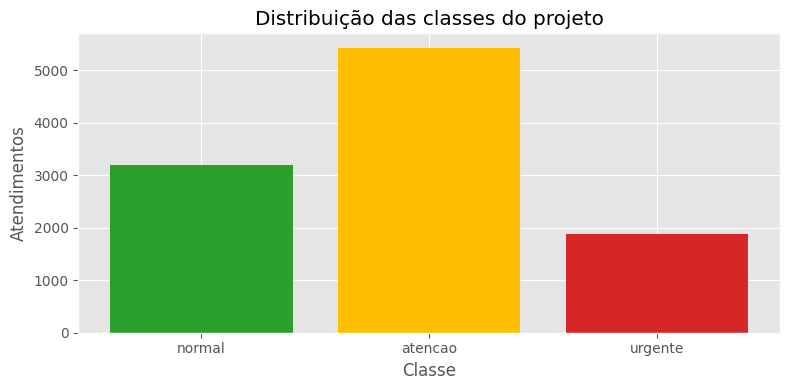

Razão entre a maior e a menor classe: 2.89x


In [5]:
eligibility = (
    raw["IMMEDR"]
    .map(immediacy_lookup)
    .fillna("Unmapped")
    .value_counts(dropna=False)
    .rename_axis("original_triage")
    .rename("rows")
    .reset_index()
)
eligibility["eligible"] = eligibility["original_triage"].isin(
    ["Immediate", "Emergent", "Urgent", "Semi-urgent", "Nonurgent"]
)
display(eligibility)

target_distribution = (
    data["target"]
    .value_counts(sort=False)
    .rename("rows")
    .to_frame()
)
target_distribution["rate"] = target_distribution["rows"] / len(data)
display(target_distribution.style.format({"rate": "{:.2%}"}))

fig, ax = plt.subplots(figsize=(8, 4))
target_plot = target_distribution.reset_index()
ax.bar(
    target_plot["target"].astype(str),
    target_plot["rows"],
    color=[TARGET_COLORS[str(target)] for target in target_plot["target"]],
)
ax.set(title="Distribuição das classes do projeto", xlabel="Classe", ylabel="Atendimentos")
plt.tight_layout()
plt.show()

imbalance_ratio = target_distribution["rows"].max() / target_distribution["rows"].min()
print(f"Razão entre a maior e a menor classe: {imbalance_ratio:.2f}x")

## 5. Completude das informações disponíveis na triagem

Ausência de sinal vital não equivale a sinal normal. O pipeline deverá manter a ausência explícita e ajustar qualquer transformação somente no conjunto de treino.

,field,available_rows,coverage
0,Primary reason for visit,10492,100.0%
2,Heart rate,10269,97.8%
3,Respiratory rate,10252,97.7%
6,Oxygen saturation,10213,97.3%
1,Temperature,10112,96.4%
4,Systolic blood pressure,9774,93.1%
5,Diastolic blood pressure,9769,93.1%
7,Pain scale,7724,73.6%


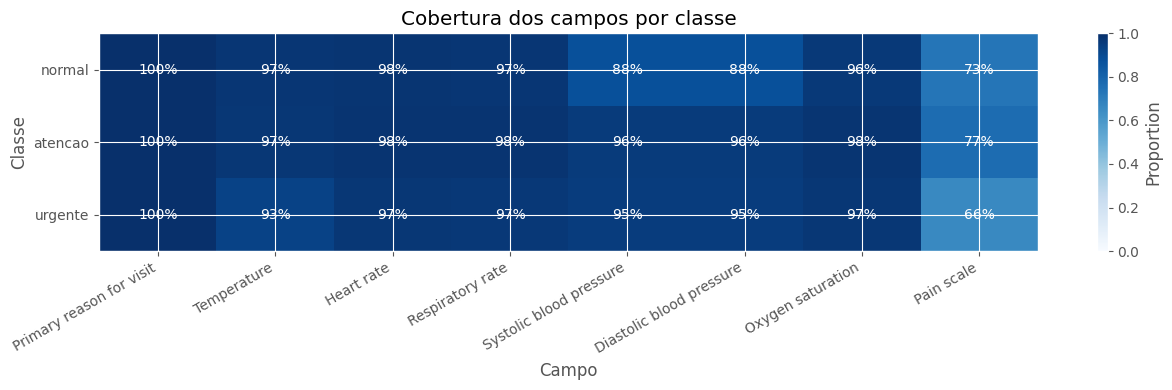

In [6]:
triage_fields = {
    "Primary reason for visit": "RFV1_description",
    "Temperature": "temperature_f",
    "Heart rate": "heart_rate",
    "Respiratory rate": "respiratory_rate",
    "Systolic blood pressure": "systolic_bp",
    "Diastolic blood pressure": "diastolic_bp",
    "Oxygen saturation": "oxygen_saturation",
    "Pain scale": "pain_scale",
}

coverage = pd.DataFrame(
    [
        {
            "field": label,
            "available_rows": int(data[column].notna().sum()),
            "coverage": data[column].notna().mean(),
        }
        for label, column in triage_fields.items()
    ]
).sort_values("coverage", ascending=False)
display(coverage.style.format({"coverage": "{:.1%}"}))

coverage_by_target = pd.DataFrame(
    {label: data.groupby("target", observed=True)[column].apply(lambda values: values.notna().mean())
     for label, column in triage_fields.items()}
)
fig, ax = plt.subplots(figsize=(13, 4))
plot_percentage_heatmap(
    coverage_by_target,
    ax=ax,
    cmap="Blues",
    title="Cobertura dos campos por classe",
    annotation_color="white",
)
ax.set(xlabel="Campo", ylabel="Classe")
plt.tight_layout()
plt.show()

## 6. Sintomas e motivos da visita por gravidade

Uma mesma queixa pode ocorrer em várias gravidades. Frequência mede prevalência no recorte; a proporção de `urgente` ajuda a localizar queixas associadas a maior prioridade, mas não define causalidade nem protocolo clínico.

target,total,normal,atencao,urgente,urgente_rate
complaint,,,,,
"Abdominal pain, cramps, spasms, NOS",1039,95,840,104,10.0%
Shortness of breath,925,103,505,317,34.3%
Chest pain,830,75,457,298,35.9%
Vomiting,802,157,556,89,11.1%
Nausea,797,99,586,112,14.1%
Cough,787,289,376,122,15.5%
"Headache, pain in head",692,165,438,89,12.9%
Fever,669,273,297,99,14.8%
"Accident, NOS",575,202,281,92,16.0%


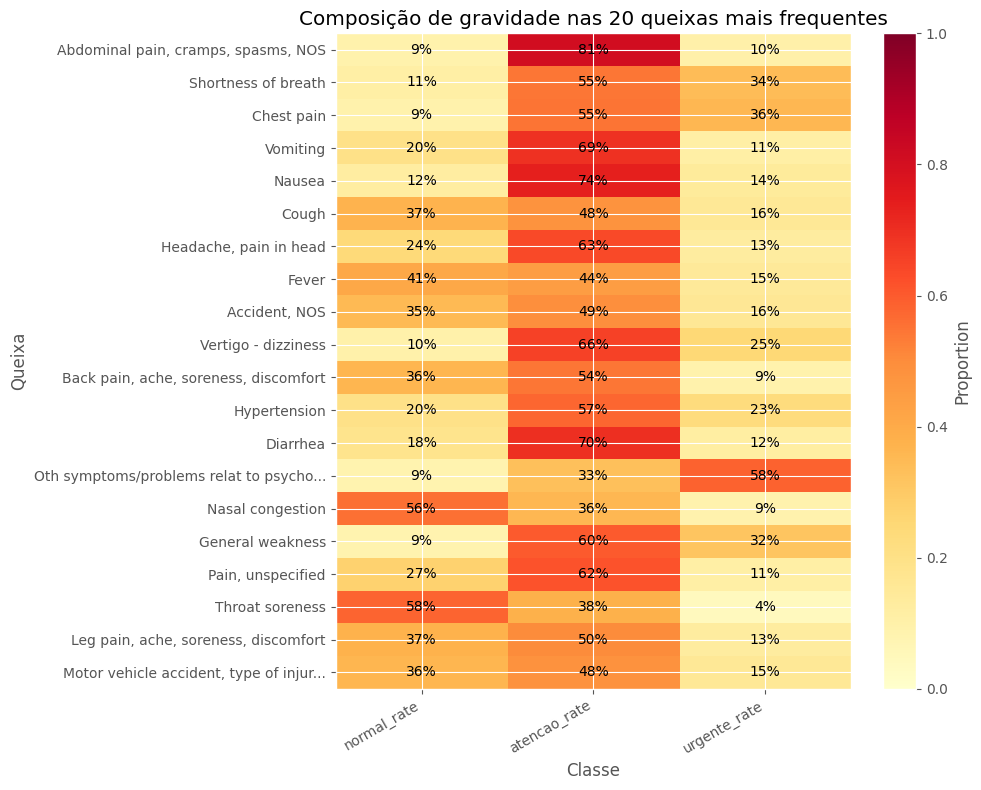

In [7]:
complaint_columns = [f"{column}_description" for column in RFV_COLUMNS]
complaints_long = (
    data.reset_index(names="visit_row")
    .melt(
        id_vars=["visit_row", "target"],
        value_vars=complaint_columns,
        value_name="complaint",
    )
    .dropna(subset=["complaint"])
)

complaint_counts = pd.crosstab(complaints_long["complaint"], complaints_long["target"])
complaint_counts = complaint_counts.reindex(columns=TARGET_ORDER, fill_value=0)
complaint_summary = complaint_counts.assign(total=complaint_counts.sum(axis=1))
for target in TARGET_ORDER:
    complaint_summary[f"{target}_rate"] = (
        complaint_summary[target] / complaint_summary["total"]
    )

top_complaints = complaint_summary.nlargest(20, "total")
display(
    top_complaints[["total", *TARGET_ORDER, "urgente_rate"]]
    .style.format({"urgente_rate": "{:.1%}"})
)

fig, ax = plt.subplots(figsize=(10, 8))
plot_percentage_heatmap(
    top_complaints[[f"{target}_rate" for target in TARGET_ORDER]],
    ax=ax,
    cmap="YlOrRd",
    title="Composição de gravidade nas 20 queixas mais frequentes",
)
ax.set(xlabel="Classe", ylabel="Queixa")
plt.tight_layout()
plt.show()

In [8]:
high_risk_complaints = (
    complaint_summary.loc[complaint_summary["total"] >= 30]
    .sort_values(["urgente_rate", "total"], ascending=[False, False])
    .head(20)
)
display(
    high_risk_complaints[["total", "normal_rate", "atencao_rate", "urgente_rate"]]
    .style.format({
        "normal_rate": "{:.1%}",
        "atencao_rate": "{:.1%}",
        "urgente_rate": "{:.1%}",
    })
)

target,total,normal_rate,atencao_rate,urgente_rate
complaint,,,,
Oth symptoms/problems relat to psycho...,327,8.6%,33.0%,58.4%
"Disorders of speech, speech disturbance",31,3.2%,38.7%,58.1%
Weakness (neurologic),42,9.5%,33.3%,57.1%
General psychiatric or psychological ...,90,8.9%,34.4%,56.7%
Unconscious on arrival,82,8.5%,35.4%,56.1%
Increased heartbeat,51,7.8%,43.1%,49.0%
Ischemic heart disease,37,16.2%,35.1%,48.6%
Adverse effect of drug abuse,63,4.8%,47.6%,47.6%
Hostile behavior,53,15.1%,39.6%,45.3%


## 7. Doenças diagnosticadas e gravidade

Os diagnósticos são úteis para interpretar a coerência clínica do target, mas são conhecidos após avaliação e investigação. Portanto, **não entram em `clinical_text` e não podem ser features do modelo**.

In [9]:
data["primary_diagnosis"] = data["DIAG1_description"].fillna(data["DIAG1_code"])
diagnosis_match_rate = data.loc[data["DIAG1_code"].notna(), "DIAG1_description"].notna().mean()
print(f"Diagnósticos primários resolvidos pela referência ICD-10-CM: {diagnosis_match_rate:.1%}")

diagnosis_counts = pd.crosstab(data["primary_diagnosis"], data["target"])
diagnosis_counts = diagnosis_counts.reindex(columns=TARGET_ORDER, fill_value=0)
diagnosis_summary = diagnosis_counts.assign(total=diagnosis_counts.sum(axis=1))
for target in TARGET_ORDER:
    diagnosis_summary[f"{target}_rate"] = (
        diagnosis_summary[target] / diagnosis_summary["total"]
    )

top_diagnoses = diagnosis_summary.nlargest(20, "total")
display(
    top_diagnoses[["total", *TARGET_ORDER, "urgente_rate"]]
    .style.format({"urgente_rate": "{:.1%}"})
)

high_risk_diagnoses = (
    diagnosis_summary.loc[diagnosis_summary["total"] >= 30]
    .sort_values(["urgente_rate", "total"], ascending=[False, False])
    .head(20)
)
display(
    high_risk_diagnoses[["total", "normal_rate", "atencao_rate", "urgente_rate"]]
    .style.format({
        "normal_rate": "{:.1%}",
        "atencao_rate": "{:.1%}",
        "urgente_rate": "{:.1%}",
    })
)

Diagnósticos primários resolvidos pela referência ICD-10-CM: 99.3%


target,total,normal,atencao,urgente,urgente_rate
primary_diagnosis,,,,,
COVID-19,334,90,181,63,18.9%
"Chest pain, unspecified",298,15,168,115,38.6%
Unspecified abdominal pain,255,28,203,24,9.4%
Pain in joint,194,112,72,10,5.2%
Other chest pain,154,24,92,38,24.7%
Dyspnea,147,8,81,58,39.5%
"Acute upper respiratory infection, unspecified",145,94,43,8,5.5%
Procedure and treatment not carried out because of patient's decision for other and unspecified reasons,139,41,87,11,7.9%
Unspecified injury of face and head,134,47,70,17,12.7%


target,total,normal_rate,atencao_rate,urgente_rate
primary_diagnosis,,,,
Other symptoms and signs involving emotional state,60,1.7%,20.0%,78.3%
Other symptoms and signs involving cognitive functions and awareness,54,7.4%,27.8%,64.8%
"Major depressive disorder, single episode, unspecified",36,5.6%,30.6%,63.9%
Unspecified atrial fibrillation and atrial flutter,35,5.7%,42.9%,51.4%
"Acute kidney failure, unspecified",42,4.8%,47.6%,47.6%
"Heart failure, unspecified",42,7.1%,47.6%,45.2%
"Anemia, unspecified",31,12.9%,41.9%,45.2%
Unspecified convulsions,61,3.3%,52.5%,44.3%
Chronic obstructive pulmonary disease with (acute) exacerbation,45,11.1%,46.7%,42.2%


## 8. Relação entre queixa principal, doença e gravidade

A tabela cruza o primeiro motivo da visita com o diagnóstico primário. Ela mostra por que uma queixa isolada não determina urgência: apresentações semelhantes podem levar a diagnósticos e prioridades diferentes.

In [10]:
complaint_diagnosis = (
    data.dropna(subset=["RFV1_description", "primary_diagnosis"])
    .groupby(["RFV1_description", "primary_diagnosis", "target"], observed=True)
    .size()
    .rename("rows")
    .reset_index()
)
pair_counts = complaint_diagnosis.pivot_table(
    index=["RFV1_description", "primary_diagnosis"],
    columns="target",
    values="rows",
    aggfunc="sum",
    fill_value=0,
    observed=True,
).reindex(columns=TARGET_ORDER, fill_value=0)
pair_summary = pair_counts.assign(total=pair_counts.sum(axis=1))
pair_summary["urgente_rate"] = pair_summary["urgente"] / pair_summary["total"]

display(
    pair_summary.loc[pair_summary["total"] >= 15]
    .sort_values(["total", "urgente_rate"], ascending=[False, False])
    .head(25)
    .style.format({"urgente_rate": "{:.1%}"})
)

,target,normal,atencao,urgente,total,urgente_rate
RFV1_description,primary_diagnosis,,,,,
Chest pain,"Chest pain, unspecified",9,121,96,226,42.5%
"Abdominal pain, cramps, spasms, NOS",Unspecified abdominal pain,13,102,9,124,7.3%
Chest pain,Other chest pain,8,57,32,97,33.0%
Shortness of breath,Dyspnea,7,43,37,87,42.5%
Fever,"Fever, unspecified",47,27,9,83,10.8%
"Headache, pain in head","Headache, unspecified",14,53,11,78,14.1%
Vertigo - dizziness,Dizziness and giddiness,7,48,13,68,19.1%
Shortness of breath,COVID-19,9,33,16,58,27.6%
COVID-19,COVID-19,6,38,12,56,21.4%


## 9. Validação externa do target com desfechos

Um target de prioridade coerente deve, em agregado, apresentar maior frequência de internação, cuidado crítico e óbito nas categorias mais graves. Esses desfechos validam a interpretação do rótulo, mas permanecem proibidos como entrada do modelo.

,visits,admission_rate,critical_care_rate,deaths_in_ed,death_rate
target,,,,,
normal,3186,2.1%,0.3%,0,0.00%
atencao,5429,11.0%,1.0%,2,0.04%
urgente,1880,32.5%,7.0%,18,0.96%


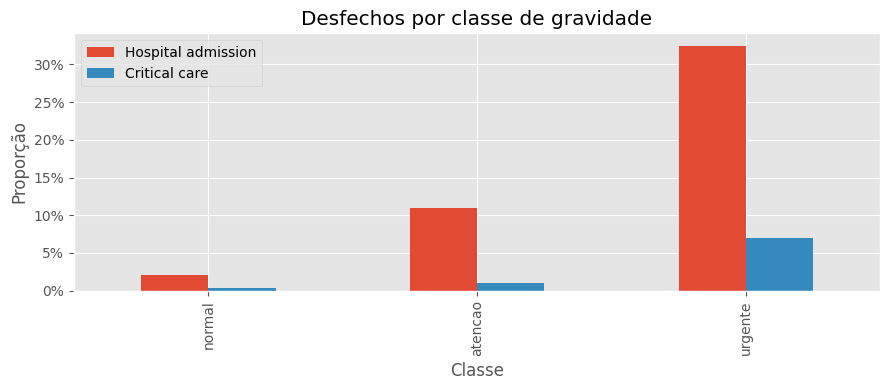

In [11]:
data["hospital_admission"] = data["ADMITHOS"].eq(1) | data["OBSHOS"].eq(1)
data["critical_care_admission"] = data["ADMIT"].eq(1)
data["died_in_ed"] = data["DIEDED"].eq(1)

outcome_summary = data.groupby("target", observed=True).agg(
    visits=("target", "size"),
    admission_rate=("hospital_admission", "mean"),
    critical_care_rate=("critical_care_admission", "mean"),
    deaths_in_ed=("died_in_ed", "sum"),
    death_rate=("died_in_ed", "mean"),
)
display(
    outcome_summary.style.format({
        "admission_rate": "{:.1%}",
        "critical_care_rate": "{:.1%}",
        "death_rate": "{:.2%}",
    })
)

plot_outcomes = outcome_summary[["admission_rate", "critical_care_rate"]].rename(
    columns={"admission_rate": "Hospital admission", "critical_care_rate": "Critical care"}
)
fig, ax = plt.subplots(figsize=(9, 4))
plot_outcomes.plot.bar(ax=ax)
ax.set(title="Desfechos por classe de gravidade", xlabel="Classe", ylabel="Proporção")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()

## 10. Sinais vitais e gravidade

Medianas não substituem faixas clínicas nem capturam extremos, mas ajudam a verificar diferenças agregadas. A alta ausência exige cautela e indicadores de missing no futuro pipeline.

temperature_f       heart_rate       respiratory_rate        \
               median count     median count           median count   
target                                                                
normal           98.2  3102       88.0  3116             18.0  3102   
atencao          98.2  5266       87.0  5327             18.0  5330   
urgente          98.2  1744       90.0  1826             18.0  1820   

        systolic_bp       oxygen_saturation       pain_scale        
             median count            median count     median count  
target                                                              
normal        130.0  2791              98.0  3067        5.0  2328  
atencao       134.0  5195              98.0  5322        5.0  4162  
urgente       135.0  1788              98.0  1824        3.0  1234

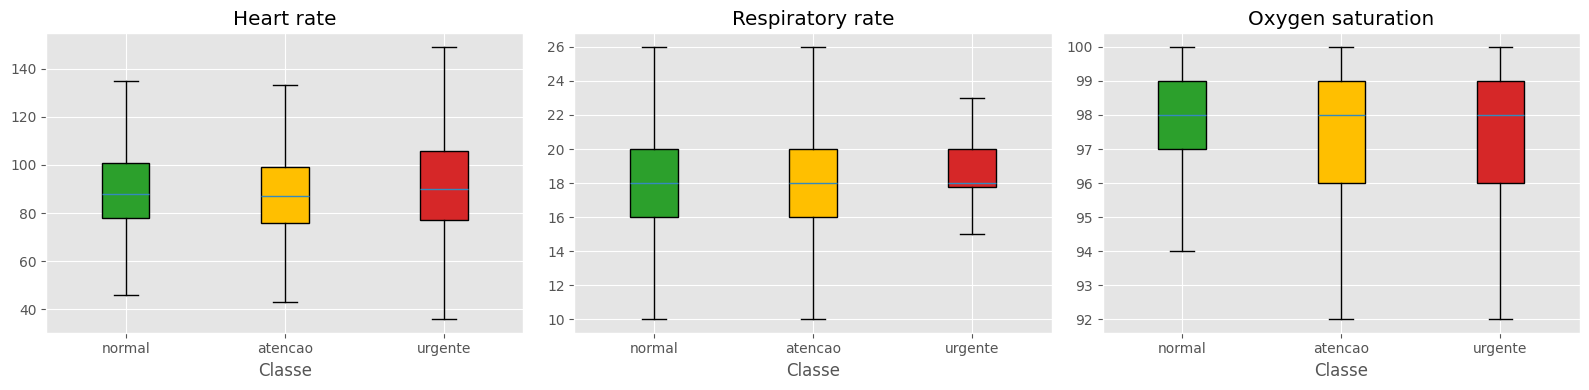

In [12]:
vital_columns = [
    "temperature_f",
    "heart_rate",
    "respiratory_rate",
    "systolic_bp",
    "oxygen_saturation",
    "pain_scale",
]
vital_summary = data.groupby("target", observed=True)[vital_columns].agg(["median", "count"])
display(vital_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, column, title in zip(
    axes,
    ["heart_rate", "respiratory_rate", "oxygen_saturation"],
    ["Heart rate", "Respiratory rate", "Oxygen saturation"],
):
    values = [data.loc[data["target"] == target, column].dropna() for target in TARGET_ORDER]
    plot = axis.boxplot(values, tick_labels=TARGET_ORDER, showfliers=False, patch_artist=True)
    for box, target in zip(plot["boxes"], TARGET_ORDER):
        box.set_facecolor(TARGET_COLORS[target])
    axis.set(title=title, xlabel="Classe", ylabel="")
plt.tight_layout()
plt.show()

## 11. Texto derivado, ambiguidade e risco de vazamento

O texto abaixo contém somente informações disponíveis na triagem. Diagnósticos e desfechos foram deliberadamente excluídos. A repetição de combinações de queixas e eventuais conflitos de rótulo precisam orientar o split e a interpretação do teto de desempenho.

In [13]:
examples = (
    data.dropna(subset=["RFV1_description"]).sort_values(["target", "RFV1"])
    .groupby("target", observed=True)
    .head(2)[["clinical_text", "target"]]
)
display(examples)

data["complaint_signature"] = data[complaint_columns].fillna("").agg(" | ".join, axis=1)
text_groups = data.groupby("clinical_text", dropna=False).agg(
    rows=("target", "size"),
    distinct_targets=("target", "nunique"),
)
complaint_groups = data.groupby("complaint_signature", dropna=False).agg(
    rows=("target", "size"),
    distinct_targets=("target", "nunique"),
)

ambiguity = pd.DataFrame(
    [
        {"representation": "Full derived clinical text", "unique_values": len(text_groups), "repeated_values": int((text_groups['rows'] > 1).sum()), "conflicting_values": int((text_groups['distinct_targets'] > 1).sum())},
        {"representation": "Complaint signature only", "unique_values": len(complaint_groups), "repeated_values": int((complaint_groups['rows'] > 1).sum()), "conflicting_values": int((complaint_groups['distinct_targets'] > 1).sum())},
    ]
)
display(ambiguity)

primary_complaint_table = pd.crosstab(data["RFV1_description"], data["target"])
primary_complaint_majority_accuracy = primary_complaint_table.max(axis=1).sum() / len(data)
print(
    "Acurácia aparente de uma regra que memoriza a classe majoritária por queixa principal: "
    f"{primary_complaint_majority_accuracy:.1%}"
)

,clinical_text,target
124,"Age: 26 years. Sex: Male. Reasons for visit: Chills; Shortness of breath; Diarrhea; Fever; COVID-19, virus not identified. Triage observ...",normal
8149,Age: 11 years. Sex: Female. Reasons for visit: Chills; Nausea; Vomiting. Triage observations: temperature 96.4 F; heart rate 83 bpm; res...,normal
562,"Age: 25 years. Sex: Male. Reasons for visit: Chills; Headache, pain in head; Nausea. Triage observations: temperature 97.3 F; heart rate...",atencao
768,Age: 31 years. Sex: Female. Reasons for visit: Chills; Chest pain; Cough; Vomiting; Personal history of COVID-19. Triage observations: t...,atencao
1302,Age: 75 years. Sex: Male. Reasons for visit: Chills; Vertigo - dizziness; Shortness of breath; Leg symptoms; Discoloration or abnormal p...,urgente
6827,"Age: 32 years. Sex: Female. Reasons for visit: Chills; Side pain, flank pain; Back pain, ache, soreness, discomfort; Other vaginal sympt...",urgente


,representation,unique_values,repeated_values,conflicting_values
0,Full derived clinical text,10492,3,0
1,Complaint signature only,6401,674,457


Acurácia aparente de uma regra que memoriza a classe majoritária por queixa principal: 63.1%


## 12. Conclusão e decisão de adequação

In [14]:
valid_rate = len(data) / len(raw)
urgent_recall_support = int((data["target"] == "urgente").sum())
rfv_coverage = data["RFV1_description"].notna().mean()
admission_monotonic = outcome_summary["admission_rate"].is_monotonic_increasing

display(
    Markdown(
        f"""
### Principais achados

- **Amostra utilizável:** {len(data):,} de {len(raw):,} atendimentos ({valid_rate:.1%}) possuem prioridade válida; o mínimo de 2.000 amostras é atendido.
- **Target:** há {urgent_recall_support:,} casos na classe `urgente`. A distribuição é desbalanceada ({imbalance_ratio:.2f}x), justificando macro F1 e recall de `urgente` como métricas centrais.
- **Sintomas:** a queixa principal está disponível em {rfv_coverage:.1%} dos casos elegíveis e possui descrições clínicas oficiais em inglês.
- **Gravidade:** a taxa de internação cresce de forma monotônica entre `normal`, `atencao` e `urgente`: **{admission_monotonic}**. Isso sustenta a interpretação clínica do target em agregado.
- **Doenças:** diagnósticos ICD-10-CM permitem relacionar apresentação, doença e gravidade na EDA, mas são informação pós-triagem e estão bloqueados como feature.
- **Texto:** `clinical_text` é uma representação determinística de campos estruturados, não a fala livre original. Essa limitação deve aparecer no Model Card.
- **Ausência:** sinais vitais e dor têm missing relevante; valores ausentes não podem ser preenchidos antes do split nem interpretados como normais.
- **Split:** textos idênticos devem permanecer no mesmo conjunto. A divisão deverá ser estratificada e agrupada pelo hash de `clinical_text`, com seed fixa.
- **Vazamento:** diagnóstico, exames, medicamentos, espera, disposição, internação, UTI e óbito ficam restritos à EDA e à validação externa.

### Decisão

O **NHAMCS-ED 2021 é adequado para o demonstrador acadêmico**, com target real de prioridade e volume suficiente. A aprovação é condicionada a manter o contrato acima: inglês como idioma de entrada, texto derivado documentado, split agrupado e exclusão rigorosa de informações posteriores à triagem.
"""
    )
)


### Principais achados

- **Amostra utilizável:** 10,495 de 16,207 atendimentos (64.8%) possuem prioridade válida; o mínimo de 2.000 amostras é atendido.
- **Target:** há 1,880 casos na classe `urgente`. A distribuição é desbalanceada (2.89x), justificando macro F1 e recall de `urgente` como métricas centrais.
- **Sintomas:** a queixa principal está disponível em 100.0% dos casos elegíveis e possui descrições clínicas oficiais em inglês.
- **Gravidade:** a taxa de internação cresce de forma monotônica entre `normal`, `atencao` e `urgente`: **True**. Isso sustenta a interpretação clínica do target em agregado.
- **Doenças:** diagnósticos ICD-10-CM permitem relacionar apresentação, doença e gravidade na EDA, mas são informação pós-triagem e estão bloqueados como feature.
- **Texto:** `clinical_text` é uma representação determinística de campos estruturados, não a fala livre original. Essa limitação deve aparecer no Model Card.
- **Ausência:** sinais vitais e dor têm missing relevante; valores ausentes não podem ser preenchidos antes do split nem interpretados como normais.
- **Split:** textos idênticos devem permanecer no mesmo conjunto. A divisão deverá ser estratificada e agrupada pelo hash de `clinical_text`, com seed fixa.
- **Vazamento:** diagnóstico, exames, medicamentos, espera, disposição, internação, UTI e óbito ficam restritos à EDA e à validação externa.

### Decisão

O **NHAMCS-ED 2021 é adequado para o demonstrador acadêmico**, com target real de prioridade e volume suficiente. A aprovação é condicionada a manter o contrato acima: inglês como idioma de entrada, texto derivado documentado, split agrupado e exclusão rigorosa de informações posteriores à triagem.
